In [ ]:
import pandas as pd

def load_data(path='data'):
    interactions = pd.read_csv(path + '/interactions.csv')
    items = pd.read_csv(path + '/items.csv')
    sample_submission = pd.read_csv(path + '/sample_submission.csv')

    # rename "interractions" columns from ('u','i', 't') to ('user_id', 'item_id', 'timestamp')
    interactions.rename(columns={'u': 'user_id', 'i': 'item_id', 't': 'timestamp'}, inplace=True)

    # rename "items" columns from ('i') to ('user_id', 'item_id', 'timestamp')
    items.rename(columns={'i': 'item_id'}, inplace=True)

    # # Remove items with 0 interactions
    # items_with_interactions = interactions["item_id"].unique()
    # items = items[items["item_id"].isin(items_with_interactions)]

    # ---- Create internal indices (consistent across datasets) ---- #

    # Unique raw IDs (only items that have interactions)
    # unique_users = interactions["user_id"].unique()
    # unique_items = items_with_interactions

    # Internal contiguous indices
    # user_index = {uid: idx for idx, uid in enumerate(unique_users)}
    # item_index = {iid: idx for idx, iid in enumerate(unique_items)}
    items_with_interactions = interactions["item_id"].unique()

    unique_users = interactions["user_id"].unique()
    unique_items = items_with_interactions
    user_index = {uid: idx for idx, uid in enumerate(unique_users)}
    item_index = {iid: idx for idx, iid in enumerate(unique_items)}

     # ---- Add internal indices to datasets ---- #

    interactions["user_idx"] = interactions["user_id"].map(user_index)
    interactions["item_idx"] = interactions["item_id"].map(item_index)

    items["item_idx"] = items["item_id"].map(item_index)

    return (
        interactions,
        items,
        sample_submission,
        user_index,
        item_index,
    )

def generate_submission(predictions, user_index, item_index, k=10):
    """
    Generate submission dataframe with top-k recommendations for each user.
    Converts internal indices back to actual user/item IDs for Kaggle submission.
    
    Parameters:
        predictions (numpy array): Predicted scores matrix (n_users x n_items).
        user_index (dict): Mapping from actual user_id to internal user_idx.
        item_index (dict): Mapping from actual item_id to internal item_idx.
        k (int): Number of top recommendations per user.
    
    Returns:
        pandas DataFrame: Submission dataframe with actual user_id and item_id recommendations.
    """
    # Create reverse mappings: internal index -> actual ID
    idx_to_user = {idx: uid for uid, idx in user_index.items()}
    idx_to_item = {idx: iid for iid, idx in item_index.items()}
    
    submissions = []
    n_users = predictions.shape[0]
    
    for user_idx in range(n_users):
        # Get top-k predicted items (sorted by predicted score, descending)
        top_k_item_indices = np.argsort(predictions[user_idx])[::-1][:k]
        
        # Convert item indices back to actual item IDs
        top_k_item_ids = [idx_to_item[idx] for idx in top_k_item_indices]
        
        # Convert to space-separated string of actual item IDs
        recommendation_str = ' '.join(map(str, top_k_item_ids))
        
        # Use actual user_id instead of internal index
        actual_user_id = idx_to_user[user_idx]
        submissions.append({'user_id': actual_user_id, 'recommendation': recommendation_str})
    
    return pd.DataFrame(submissions)

def print_comparison(results):
    """Display comparison of different recommendation methods."""
    print("\n" + "="*60)
    print("RECOMMENDATION SYSTEM COMPARISON")
    print("="*60)
    
    for method, metrics in results.items():
        print(f"\n{method}:")
        print(f"  MAP@10: {metrics['map_score']:.4f}")
        print(f"  Submission saved: {metrics['submission_path']}")
    
    print("\n" + "="*60)
    best_method = max(results.items(), key=lambda x: x[1]['map_score'])
    print(f"Best Method: {best_method[0]} (MAP@10: {best_method[1]['map_score']:.4f})")
    print("="*60 + "\n")

Interractions: (87047, 5)
Items: (15291, 7)
Index(['user_id', 'item_id', 'timestamp', 'user_idx', 'item_idx'], dtype='object')
Using device: cpu
{'users': tensor([2949, 6869, 7405, 1094, 5026, 6577,  385, 2838,  879, 3687]), 'items': tensor([ 4475, 15040,  3030,   888, 10293,  8524,  4391, 11171,  6811,  8546]), 'interactions': tensor([ 1.,  6., 14.,  1.,  3.,  1., 10.,  1.,  1.,  1.])}
7838
15109
7837
15108
tensor([2949, 6869, 7405, 1094, 5026, 6577,  385, 2838,  879, 3687])
torch.Size([10])
tensor([ 4475, 15040,  3030,   888, 10293,  8524,  4391, 11171,  6811,  8546])
torch.Size([10])
tensor([ 1.,  6., 14.,  1.,  3.,  1., 10.,  1.,  1.,  1.])
torch.Size([10])
user embeddings torch.Size([10, 32])
item embeddings torch.Size([10, 32])
model_output : tensor([[-0.3110],
        [ 0.5911],
        [ 0.2245],
        [-1.1491],
        [ 1.0207],
        [-0.7524],
        [-1.1298],
        [ 0.1211],
        [ 0.7100],
        [ 0.5058]]), site: torch.Size([10, 1])


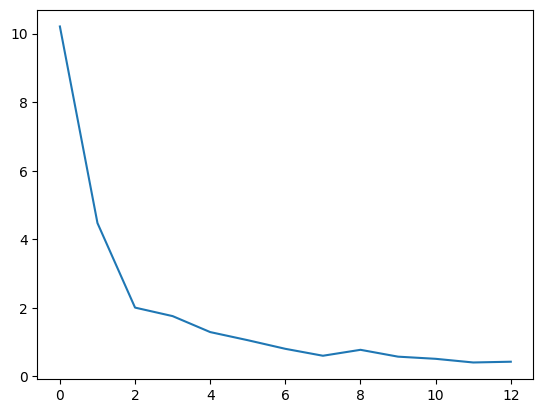

user: 6186, item: 45, pred_ranking: 3.2596871852874756, true_ranking: 1.0
user: 1586, item: 4485, pred_ranking: 1.3894476890563965, true_ranking: 6.0
user: 222, item: 2912, pred_ranking: 1.289636254310608, true_ranking: 14.0
user: 5976, item: 5372, pred_ranking: 1.210060477256775, true_ranking: 1.0
user: 4084, item: 2628, pred_ranking: 2.0465173721313477, true_ranking: 3.0
user: 1155, item: 4783, pred_ranking: 1.82624351978302, true_ranking: 1.0
user: 1884, item: 11410, pred_ranking: 3.4120285511016846, true_ranking: 10.0
user: 2481, item: 2393, pred_ranking: 0.9582512378692627, true_ranking: 1.0
user: 4821, item: 3437, pred_ranking: 3.2651755809783936, true_ranking: 1.0
user: 3304, item: 9058, pred_ranking: 0.4447062015533447, true_ranking: 1.0
user: 3358, item: 13136, pred_ranking: 1.0964992046356201, true_ranking: 1.0
user: 522, item: 5536, pred_ranking: 2.550316572189331, true_ranking: 6.0
user: 4363, item: 2003, pred_ranking: 0.552299976348877, true_ranking: 14.0
user: 3350, item:

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1 Load Data
interactions, items, sample_submission, user_index, item_index, = load_data(path='data')
print(f"Interractions: {interactions.shape}")
print(f"Items: {items.shape}")

import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn import model_selection, metrics, preprocessing
from torch.utils.data import DataLoader, Dataset


df = interactions.copy()
print(df.columns)
device = torch.device('cpu' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

class ItemDataset:
    def __init__(self, interactions, items, users):
        self.interactions = interactions
        self.items = items
        self.users= users

    def __len__(self):
        return len(self.users)
    
    def __getitem__(self, idx):
        user = self.users[idx]
        item = self.items[idx]
        interaction = self.interactions[idx]

        return {
            'users': torch.tensor(user, dtype=torch.long),
            'items': torch.tensor(item, dtype=torch.long),
            'interactions': torch.tensor(interaction, dtype=torch.float)
        }

class RecSysModel(nn.Module):
    def __init__(self, n_users, n_items, n_factors=32):
        super().__init__()
        self.user_embedding = nn.Embedding(n_users, n_factors)
        self.item_embedding = nn.Embedding(n_items, n_factors)
        # self.user_bias = nn.Embedding(n_users, 1)
        # self.item_bias = nn.Embedding(n_items, 1)
        self.out = nn.Linear(n_factors*2, 1)
    def forward(self, users, items):
        user_embed = self.user_embedding(users)
        item_embed = self.item_embedding(items)
        # user_bias = self.user_bias(users)
        # item_bias = self.item_bias(items)
        output = torch.cat([user_embed, item_embed], dim=1)
        output = self.out(output)
        return output


# encode the user and item ids to start from 0 so we don't run into index out of bounds with the embeddings
lbl_user = preprocessing.LabelEncoder()
lbl_item = preprocessing.LabelEncoder()
df['userId'] = lbl_user.fit_transform(df['user_id'].values)
df['itemId'] = lbl_item.fit_transform(df['item_id'].values)

df["datetime"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.sort_values("timestamp").reset_index(drop=True)

# Add interaction index within each (u, i) pair
df["interaction_rank"] = df.groupby(["user_id", "item_id"]).cumcount() + 1

split_idx = int(len(df) * 0.8)
train_data = df.iloc[:split_idx]
test_data = df.iloc[split_idx:]


# # Aggregate interactions: count how many times each (user, item) pair occurred
# implicit_df = df.groupby(['userId', 'itemId']).size().reset_index(name='borrow_count')

# # Option A: Binary (just 0 or 1)
# implicit_df['interaction'] = 1.0

train_data = ItemDataset(
    interactions=train_data["target"].values,
    items=train_data['itemId'].values,
    users=train_data['userId'].values
)




test_data = ItemDataset(
    interactions=test_data["target"].values,
    items=test_data['itemId'].values,
    users=test_data['userId'].values
)

train_loader = DataLoader(train_data, batch_size=10, shuffle=True, num_workers=0)
test_loader = DataLoader(test_data, batch_size=10, shuffle=True, num_workers=0)


dataiter = iter(train_loader)
dataloader_data = next(dataiter)


model = RecSysModel(n_users=len(lbl_user.classes_), n_items=len(lbl_item.classes_)).to(device)

optimizer = torch.optim.Adam(model.parameters())
sch = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.7)

loss_fn = nn.MSELoss()

    
print(dataloader_data)


print(len(lbl_user.classes_))
print(len(lbl_item.classes_))
print(df['userId'].max())
print(df['itemId'].max())
print(dataloader_data['users'])

print(dataloader_data['users'].size())
print(dataloader_data['items'])
print(dataloader_data['items'].size())
print(dataloader_data['interactions'])
print(dataloader_data['interactions'].size())


user_embed = nn.Embedding(len(lbl_user.classes_), 32)
item_embed = nn.Embedding(len(lbl_item.classes_), 32)


user_embeddings = user_embed(dataloader_data['users'])
item_embeddings = item_embed(dataloader_data['items'])

print(f'user embeddings {user_embeddings.size()}')
print(f'item embeddings {item_embeddings.size()}')

out = nn.Linear(32*2, 1)

user_embeddings = user_embed(dataloader_data['users'])
item_embeddings = item_embed(dataloader_data['items'])

output = torch.cat([user_embeddings, item_embeddings], dim=1)
output = out(output)


with torch.no_grad():
    model_output = model(dataloader_data['users'], dataloader_data['items'])

print(f"model_output : {model_output}, site: {model_output.size()}")

interactions = dataloader_data['interactions']

epochs = 1
total_loss = 0
plot_steps, print_steps = 5000, 5000
step_cnt = 0
all_losses_list = []
batch_size = 10

model.train()

for epoch in range(epochs):
    for i, train_data in enumerate(train_loader):

        users = batch['users'].to(device)
        items = batch['items'].to(device)
        targets = batch['targets'].to(device)
        output = model(users, items)
        loss = loss_fn(output.squeeze(), targets)
        total_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        step_cnt = step_cnt + len(train_data['users'])

        if step_cnt % plot_steps == 0:
            avg_loss = total_loss / (step_cnt // batch_size)            
            all_losses_list.append(avg_loss)
            total_loss = 0



plt.figure()
plt.plot(all_losses_list)
plt.show()


from collections import defaultdict

user_est_true = defaultdict(list)

with torch.no_grad():
    for i, batched_data in enumerate(test_loader):
        users = batched_data['users'].to(device)
        items = batched_data['items'].to(device)
        ranking = batched_data['interactions'].to(device)

        output = model(batched_data['users'], batched_data['items'])

        for i in range(len(users)):
            user = users[i].item()
            item = items[i].item()
            pred_ranking = output[i].item()
            true_ranking = interactions[i].item()

            print(f"user: {user}, item: {item}, pred_ranking: {pred_ranking}, true_ranking: {true_ranking}")
            user_est_true[user].append((pred_ranking, true_ranking))

        
        
with torch.no_grad():
    precisions = dict()
    recalls = dict()

    k = 10
    threshold = 1
    for uid, user_rankings in user_est_true.items():
        user_rankings.sort(key=lambda x: x[0], reverse=True)
        n_rel = sum((true_ranking >= threshold) for (pred_ranking, true_ranking) in user_rankings)
        n_rec = k
        n_rel_and_rec = sum(((true_ranking >= threshold) and (pred_ranking >= threshold)) for (pred_ranking, true_ranking) in user_rankings)

        precisions[uid] = n_rel_and_rec / n_rec if n_rec != 0 else 1.0
        recalls[uid] = n_rel_and_rec / n_rel if n_rel != 0 else 1.0

    print(f"Precision: {sum(prec for prec in precisions.values()) / len(precisions)}")
    print(f"Recall: {sum(rec for rec in recalls.values()) / len(recalls)}")
        
        
        

print(f"precistion @ {k}: {sum(prec for prec in precisions.values())  /len(precisions) }")
print(f"recall @ {k} : {sum(rec for rec in recalls.values()) / len(recalls)}")



In [9]:
# ============================================================
# GENERATE SUBMISSION FOR ALL USERS
# ============================================================

from datetime import datetime
from tqdm import tqdm

def generate_submission_from_model(model, interactions_df, lbl_user, lbl_item, sample_submission_path='data/sample_submission.csv', output_dir='data/submissions', top_k=10, exclude_known=True):
    """
    Generate submission file with top-k recommendations for all users.
    
    Parameters:
        model: Trained RecSysModel
        interactions_df: DataFrame with user interactions (for excluding known items)
        lbl_user: LabelEncoder for user IDs
        lbl_item: LabelEncoder for item IDs
        sample_submission_path: Path to sample submission CSV
        output_dir: Directory to save submission
        top_k: Number of recommendations per user
        exclude_known: Whether to exclude items user has already interacted with
    
    Returns:
        submission_df: DataFrame with submission
        output_path: Path to saved submission file
    """
    import os
    os.makedirs(output_dir, exist_ok=True)
    
    # Load sample submission to get all user IDs
    sample_sub = pd.read_csv(sample_submission_path)
    submission_user_ids = sample_sub['user_id'].values
    
    # Get all item indices
    n_items = len(lbl_item.classes_)
    all_item_indices = torch.arange(n_items, dtype=torch.long).to(device)
    
    # Build known items per user (using internal IDs)
    if exclude_known:
        user_known_items = interactions_df.groupby('userId')['itemId'].apply(set).to_dict()
    
    model.eval()
    submissions = []
    
    with torch.no_grad():
        for user_id in tqdm(submission_user_ids, desc="Generating predictions"):
            # Check if user exists in our training data
            if user_id not in lbl_user.classes_:
                # Cold-start user: use most popular items
                popular_items = interactions_df['item_id'].value_counts().head(top_k).index.tolist()
                recommendation_str = ' '.join(map(str, popular_items))
                submissions.append({'user_id': user_id, 'recommendation': recommendation_str})
                continue
            
            # Get internal user index
            user_idx = lbl_user.transform([user_id])[0]
            user_tensor = torch.tensor([user_idx] * n_items, dtype=torch.long).to(device)
            
            # Predict scores for all items
            scores = model(user_tensor, all_item_indices).squeeze().cpu().numpy()
            
            # Exclude known items if requested
            if exclude_known and user_idx in user_known_items:
                known_items = user_known_items[user_idx]
                for known_idx in known_items:
                    scores[known_idx] = -np.inf
            
            # Get top-k item indices
            top_k_item_indices = np.argsort(scores)[::-1][:top_k]
            
            # Convert internal item indices back to original item IDs
            top_k_item_ids = lbl_item.inverse_transform(top_k_item_indices)
            
            # Format as space-separated string
            recommendation_str = ' '.join(map(str, top_k_item_ids))
            submissions.append({'user_id': user_id, 'recommendation': recommendation_str})
    
    # Create submission DataFrame
    submission_df = pd.DataFrame(submissions)
    
    # Save to file
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    output_path = f"{output_dir}/submission_neural_net_{timestamp}.csv"
    submission_df.to_csv(output_path, index=False)
    
    print(f"\n{'='*60}")
    print(f"SUBMISSION GENERATED SUCCESSFULLY")
    print(f"{'='*60}")
    print(f"Output path: {output_path}")
    print(f"Total users: {len(submission_df)}")
    print(f"Recommendations per user: {top_k}")
    print(f"\nSample submissions:")
    print(submission_df.head())
    print(f"\n{'='*60}")
    
    return submission_df, output_path


# Generate submission using the trained model
submission_df, submission_path = generate_submission_from_model(
    model=model,
    interactions_df=df,
    lbl_user=lbl_user,
    lbl_item=lbl_item,
    sample_submission_path='data/sample_submission.csv',
    output_dir='data/submissions',
    top_k=10,
    exclude_known=True
)

# Verify the submission format matches expected
print("\nVerifying submission format...")
sample = pd.read_csv('data/sample_submission.csv')
print(f"Expected rows: {len(sample)}, Got: {len(submission_df)}")
print(f"Expected columns: {list(sample.columns)}, Got: {list(submission_df.columns)}")

# Check that recommendations have exactly 10 items
rec_lengths = submission_df['recommendation'].apply(lambda x: len(x.split()))
print(f"Recommendation lengths - Min: {rec_lengths.min()}, Max: {rec_lengths.max()}, Mean: {rec_lengths.mean():.1f}")


Generating predictions: 100%|██████████| 7838/7838 [00:27<00:00, 280.28it/s]


SUBMISSION GENERATED SUCCESSFULLY
Output path: data/submissions/submission_neural_net_20251214_011628.csv
Total users: 7838
Recommendations per user: 10

Sample submissions:
   user_id                                     recommendation
0        0  10715 14578 11184 4426 14238 7111 7324 8474 30...
1        1  10715 14578 11184 4426 14238 7111 7324 8474 30...
2        2  10715 14578 11184 4426 14238 7111 7324 8474 30...
3        3  10715 14578 11184 4426 14238 7111 7324 8474 30...
4        4  10715 14578 11184 4426 14238 7111 7324 8474 30...


Verifying submission format...
Expected rows: 7838, Got: 7838
Expected columns: ['user_id', 'recommendation'], Got: ['user_id', 'recommendation']
Recommendation lengths - Min: 10, Max: 10, Mean: 10.0
